# Lab 0: GitHub Setup & Python Foundations

Name: *(replace with your name)*

Run each cell in order. Complete the "Try it yourself" sections in the empty cell right below each example.

In [2]:
import numpy, pandas, matplotlib, sklearn, tensorflow
print("Environment OK — all libraries loaded")
print("TensorFlow version:", tensorflow.__version__)

I0000 00:00:1788201963.258736   30653 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788201963.259495   30653 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788201963.324785   30653 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788201968.747407   30653 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Environment OK — all libraries loaded
TensorFlow version: 2.21.0


## Part B — NumPy: Vectors and Matrix Multiplication

In [3]:
import numpy as np

# Vectors
v1 = np.array([1, 2, 3])
v2 = np.array([4, 5, 6])
print("Dot product:", np.dot(v1, v2))

# Matrices
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])
print("Matrix product:\n", np.matmul(A, B))

# Why this matters: a neural network layer is just
# inputs @ weights + bias — matrix multiplication under the hood
inputs = np.array([0.5, 0.8, 0.2])
weights = np.array([0.1, -0.3, 0.7])
bias = 0.1
output = np.dot(inputs, weights) + bias
print("Simple neuron output:", output)

Dot product: 32
Matrix product:
 [[19 22]
 [43 50]]
Simple neuron output: 0.04999999999999999


**Try it yourself:** Change the `weights` and `inputs` values above and observe how the output changes. Add one more input and check — does it still work? Why or why not? Write your code and answer in the cell below.

No, it does not work if you only add an input without adding a matching weight. The dot product requires both vectors to have the same length. Each input must have a corresponding weight. If you add a fourth input, you must also add a fourth weight, otherwise NumPy raises a ValueError: shapes (4,) and (3,) not aligned. This mirrors how a real neural network layer works: every input neuron connects to every weight in the next layer, so the dimensions must match.

In [4]:
# Your code and answer here
import numpy as np

# Vectors
v1 = np.array([1, 2, 3])
v2 = np.array([4, 5, 6])
print("Dot product:", np.dot(v1, v2))

# Matrices
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])
print("Matrix product:\n", np.matmul(A, B))

# Why this matters: a neural network layer is just
# inputs @ weights + bias — matrix multiplication under the hood
inputs = np.array([0.6, 0.2, 0.3, 0.4])
weights = np.array([0.1, -0.3, 0.7])
bias = 0.1
output = np.dot(inputs, weights) + bias
print("Simple neuron output:", output)

Dot product: 32
Matrix product:
 [[19 22]
 [43 50]]


ValueError: shapes (4,) and (3,) not aligned: 4 (dim 0) != 3 (dim 0)

## Part C — Pandas: Working with Tabular Data

In [5]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
df = iris.frame
print(df.head())
print(df.describe())

# Filter: only rows where petal length > 5
long_petals = df[df['petal length (cm)'] > 5]
print(long_petals.shape)

# Group by target class and get average measurements
print(df.groupby('target').mean())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000  

**Try it yourself:** Filter the dataframe for a different condition of your choosing (e.g., sepal width above some value), and print how many rows match.

In [7]:
# Your code here
wide_sepals = df[df['sepal width (cm)'] > 3.5]
print(f"Rows matching condition: {wide_sepals.shape[0]}")
print(wide_sepals)

Rows matching condition: 19
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
4                  5.0               3.6                1.4               0.2   
5                  5.4               3.9                1.7               0.4   
10                 5.4               3.7                1.5               0.2   
14                 5.8               4.0                1.2               0.2   
15                 5.7               4.4                1.5               0.4   
16                 5.4               3.9                1.3               0.4   
18                 5.7               3.8                1.7               0.3   
19                 5.1               3.8                1.5               0.3   
21                 5.1               3.7                1.5               0.4   
22                 4.6               3.6                1.0               0.2   
32                 5.2               4.1                1.5               0.1   


## Part D — Matplotlib: Basic Plotting

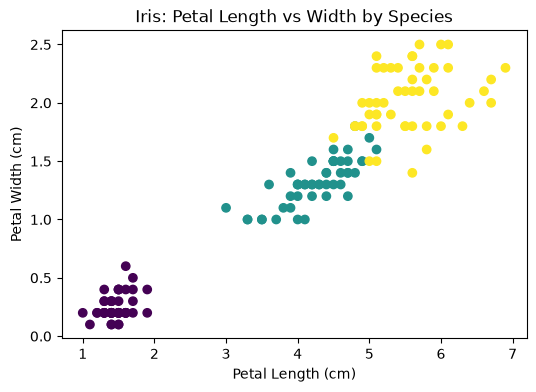

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(df['petal length (cm)'], df['petal width (cm)'], c=df['target'])
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Iris: Petal Length vs Width by Species')
plt.show()

**Try it yourself:** Make a second plot comparing two different columns from the dataset.

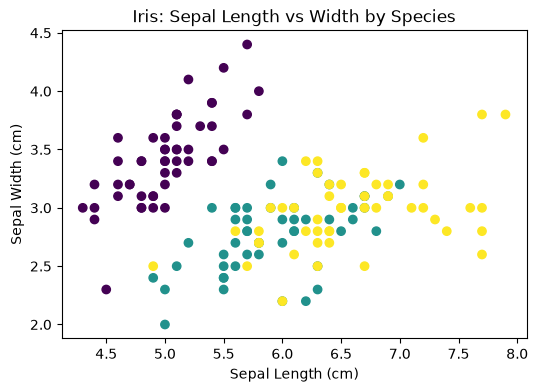

In [9]:
# Your code here
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(df['sepal length (cm)'], df['sepal width (cm)'], c=df['target'])
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Iris: Sepal Length vs Width by Species')
plt.show()

## Part E — Bonus: See a Real Model Run (optional)

This loads a model already trained on 1.4 million images and asks it to classify a photo it's never seen — the same basic pattern (load a pretrained model, run inference) you'll use later this semester.

61306/61306 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


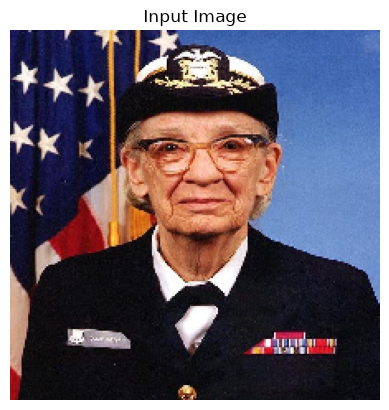

E0000 00:00:1788202451.687694   30653 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Top 3 predictions:
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
  military_uniform: 88.2%
  suit: 1.3%
  Windsor_tie: 0.6%


In [8]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Download a sample image (cached after first run)
img_path = tf.keras.utils.get_file(
    'grace_hopper.jpg',
    'https://storage.googleapis.com/download.tensorflow.org/example_images/grace_hopper.jpg'
)

# Load and display the image
img = image.load_img(img_path, target_size=(224, 224))
plt.imshow(img)
plt.axis('off')
plt.title('Input Image')
plt.show()

# Run inference
model = MobileNetV2(weights='imagenet')
x = preprocess_input(np.expand_dims(image.img_to_array(img), axis=0))
preds = model.predict(x)

# Show the predictions
print("Top 3 predictions:")
for label, name, confidence in decode_predictions(preds, top=3)[0]:
    print(f"  {name}: {confidence*100:.1f}%")

## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.